# Experimental to make motor mapping 

In [1]:
import os
os.environ["MUJOCO_GL"] = "egl"
import sys 
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plotting
import numpy as np
sys.path.append("/its/home/drs25/pose-to-biped")
from pose import PoseExtractor, PARENTS
import cv2
from sim import MujocoSimulator
import mujoco 


2026-03-16 14:37:28.464840: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-16 14:37:28.504494: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-16 14:37:28.505535: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-16 14:37:29.076505: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


## Get data
### Gather some coords

In [2]:
extractor = PoseExtractor(missing_value=-1.0)
cap = cv2.VideoCapture("/its/home/drs25/pose-to-biped/assets/walking.mp4")
coords=[]
for i in range(100):
    ret, frame = cap.read()
    if not ret:
        break
    landmarks = extractor.process(frame)
    landmarks,_=extractor.to_local_space(landmarks)
    coords.append(landmarks)
cap.release()

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Number of joints: 20
Number of degrees of freedom (qpos): 26
Number of actuators: 19


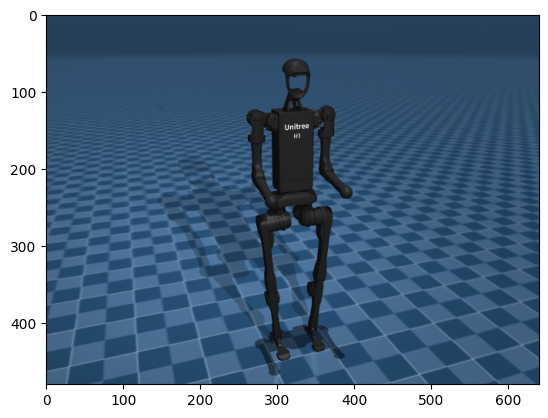

In [3]:
sim = MujocoSimulator(
            "/its/home/drs25/mujoco-menagerie-main/unitree_h1/scene.xml")
max_w = sim.model.vis.global_.offwidth
max_h = sim.model.vis.global_.offheight
renderer = mujoco.Renderer(sim.model, height=max_h, width=max_w)
sim.set_step(1)
coords2=[]
for i in range(100):
    landmarks=sim.get_coordinates()
    coords2.append(landmarks)   
    sim.set_step(1)
    renderer.update_scene(sim.data)
pixels = renderer.render()
plt.imshow(pixels)
plt.show()


In [13]:
def plot(landmarks,landmarks2):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    # Plot landmarks
    ax.scatter(landmarks[:,0], landmarks[:,1], landmarks[:,2], c='b', s=20)
    ax.scatter(landmarks2[:,0], landmarks2[:,1], landmarks2[:,2], c='r', s=20)
    for i, (x, y, z) in enumerate(landmarks):
        ax.text(x, y, z, str(i), color='blue')
    for i, (x, y, z) in enumerate(landmarks2):
        ax.text(x, y, z, str(i), color='red')
    valid_mask = landmarks[:, 0] != extractor.missing_value
    points = landmarks[valid_mask]
    for start, end in extractor.mp_pose.POSE_CONNECTIONS:
        if (
            start < len(valid_mask)
            and end < len(valid_mask)
            and valid_mask[start]
            and valid_mask[end]
        ):
            xs = [landmarks[start, 0], landmarks[end, 0]]
            ys = [landmarks[start, 1], landmarks[end, 1]]
            zs = [landmarks[start, 2], landmarks[end, 2]]

            ax.plot(xs, ys, zs, c="blue")
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    ax.set_zlabel("Z (m)")
    ax.set_title("World Pose")
    # Make all axes equal
    x_range = landmarks[:,0].max() - landmarks[:,0].min()
    y_range = landmarks[:,1].max() - landmarks[:,1].min()
    z_range = landmarks[:,2].max() - landmarks[:,2].min()
    max_range = max(x_range, y_range, z_range)

    # Compute midpoints
    x_mid = (landmarks[:,0].max() + landmarks[:,0].min()) / 2
    y_mid = (landmarks[:,1].max() + landmarks[:,1].min()) / 2
    z_mid = (landmarks[:,2].max() + landmarks[:,2].min()) / 2

    # Set limits symmetrically around the midpoint
    ax.set_xlim(x_mid - max_range/2, x_mid + max_range/2)
    ax.set_ylim(y_mid - max_range/2, y_mid + max_range/2)
    ax.set_zlim(z_mid - max_range/2, z_mid + max_range/2)

    #ax.view_init(elev=270, azim=-270)
    plt.show()

In [49]:
def scale(human_pose,robot_pose):
    robot_shoulder_to_foot=np.linalg.norm(((robot_pose[12]+robot_pose[16])/2)-((robot_pose[10]+robot_pose[5])/2))
    human_should_to_foot=np.linalg.norm(((human_pose[12]+human_pose[11])/2)-((human_pose[30]+human_pose[29])/2))
    return robot_shoulder_to_foot/human_should_to_foot
def rotate(human_pose,robot_pose):
    H = human_pose[[12,11,29,30]]
    R = robot_pose[[11,12,5,10]] 
    Hc = H - H.mean(axis=0)
    Rc = R - R.mean(axis=0)
    C = Hc.T @ Rc # covariance matrix
    U, S, Vt = np.linalg.svd(C) #SVD
    R = Vt.T @ U.T # compute rotation
    return R
def offset(human_pose,robot_pose):
    human_center = human_pose.mean(axis=0)
    robot_center = robot_pose.mean(axis=0)
    return robot_center - human_center 

[[ 0.9081979   0.39189685 -0.14694707]
 [-0.38116237  0.91946835  0.09640125]
 [ 0.17289253 -0.03154071  0.98443555]]


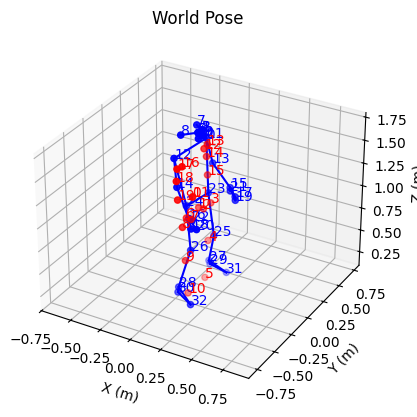

In [51]:
landmarks=coords[5][:,0:3]
hips=sim.gethips()
landmarks=landmarks+hips
landmarks2=np.array(list(coords2[5].values()))

s=scale(landmarks,landmarks2)
R=rotate(landmarks,landmarks2) 
print(R)
landmarks=s = s*(landmarks @ R.T) - offset(landmarks,landmarks2)
plot(landmarks,landmarks2)

### Plot

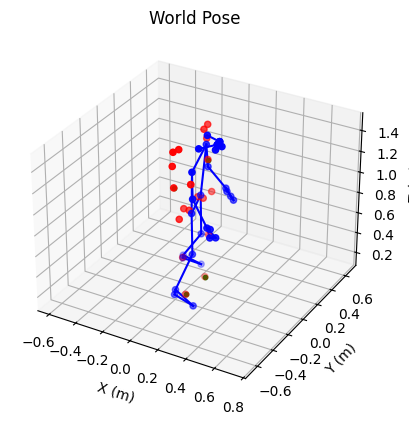

In [4]:
landmarks=coords[5][:,0:3]
hips=sim.gethips()
landmarks=landmarks+hips
landmarks2=np.array(list(coords2[5].values()))
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
# Plot landmarks
ax.scatter(landmarks[:,0], landmarks[:,1], landmarks[:,2], c='b', s=20)
ax.scatter(landmarks2[:,0], landmarks2[:,1], landmarks2[:,2], c='r', s=20)
points=sim.get_coords_of(["right_elbow", "left_elbow", "right_ankle","left_ankle"])
for i in range(len(points)):
    point=points[i]
    ax.scatter(point[0], point[1], point[2], c="green", s=10)
valid_mask = landmarks[:, 0] != extractor.missing_value
points = landmarks[valid_mask]
for start, end in extractor.mp_pose.POSE_CONNECTIONS:
    if (
        start < len(valid_mask)
        and end < len(valid_mask)
        and valid_mask[start]
        and valid_mask[end]
    ):
        xs = [landmarks[start, 0], landmarks[end, 0]]
        ys = [landmarks[start, 1], landmarks[end, 1]]
        zs = [landmarks[start, 2], landmarks[end, 2]]

        ax.plot(xs, ys, zs, c="blue")
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_zlabel("Z (m)")
ax.set_title("World Pose")
# Make all axes equal
x_range = landmarks[:,0].max() - landmarks[:,0].min()
y_range = landmarks[:,1].max() - landmarks[:,1].min()
z_range = landmarks[:,2].max() - landmarks[:,2].min()
max_range = max(x_range, y_range, z_range)

# Compute midpoints
x_mid = (landmarks[:,0].max() + landmarks[:,0].min()) / 2
y_mid = (landmarks[:,1].max() + landmarks[:,1].min()) / 2
z_mid = (landmarks[:,2].max() + landmarks[:,2].min()) / 2

# Set limits symmetrically around the midpoint
ax.set_xlim(x_mid - max_range/2, x_mid + max_range/2)
ax.set_ylim(y_mid - max_range/2, y_mid + max_range/2)
ax.set_zlim(z_mid - max_range/2, z_mid + max_range/2)

#ax.view_init(elev=270, azim=-270)
plt.show()

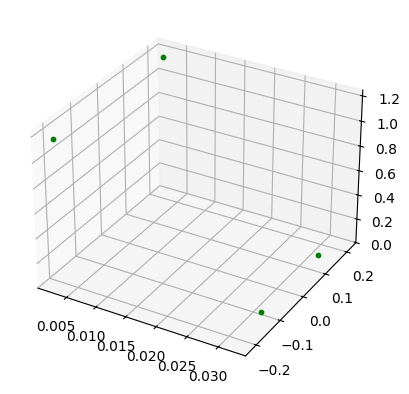

In [6]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
points=sim.get_coords_of(["right_elbow", "left_elbow", "right_ankle","left_ankle"])
for i in range(len(points)):
    point=points[i]
    ax.scatter(point[0], point[1], point[2], c="green", s=10)

plt.show()